# Gold Market Trend Analysis & Price Forecast
### Daron Nyarko | October 2024 – February 2025

---

## Executive Summary

This analysis examines gold price dynamics from January 2022 through December 2024, 
a period defined by aggressive monetary tightening, geopolitical instability, and a 
historic breakout to all-time highs. Using historical price data, macro event mapping, 
and technical trend analysis, this memo presents a **bullish thesis** on gold's 
near-term trajectory with a 60-day price target of **$2,879/oz**.

---

## Methodology

- **Data Source:** Gold Futures (GC=F) via Yahoo Finance — 752 trading days (Jan 2022 – Dec 2024)
- **Technical Indicators:** 50-Day and 200-Day Simple Moving Averages; Golden/Death Cross detection
- **Forecast Model:** Linear regression on trailing 120-day price momentum, projected 60 business days forward with an expanding ±1 standard deviation uncertainty band
- **Macro Framework:** Key geopolitical and monetary policy events annotated against price action to identify liquidity patterns and directional catalysts

---

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('dark_background')
sns.set_palette("muted")

print("All libraries loaded successfully")

All libraries loaded successfully


In [5]:
# Pull historical gold price data

# GC=F = Gold Futures (front-month contract) — most liquid gold price benchmark
gold = yf.download("GC=F", start="2022-01-01", end="2024-12-31", auto_adjust=True)

#Keep only the closing price
gold = gold[["Close"]]
gold.columns = ["Gold_Price"]

#Check
print(gold.shape)
print(gold.head())
print(gold.tail())



[*********************100%***********************]  1 of 1 completed

(752, 1)
             Gold_Price
Date                   
2022-01-03  1799.400024
2022-01-04  1814.000000
2022-01-05  1824.599976
2022-01-06  1788.699951
2022-01-07  1797.000000
             Gold_Price
Date                   
2024-12-23  2612.300049
2024-12-24  2620.000000
2024-12-26  2638.800049
2024-12-27  2617.199951
2024-12-30  2606.100098


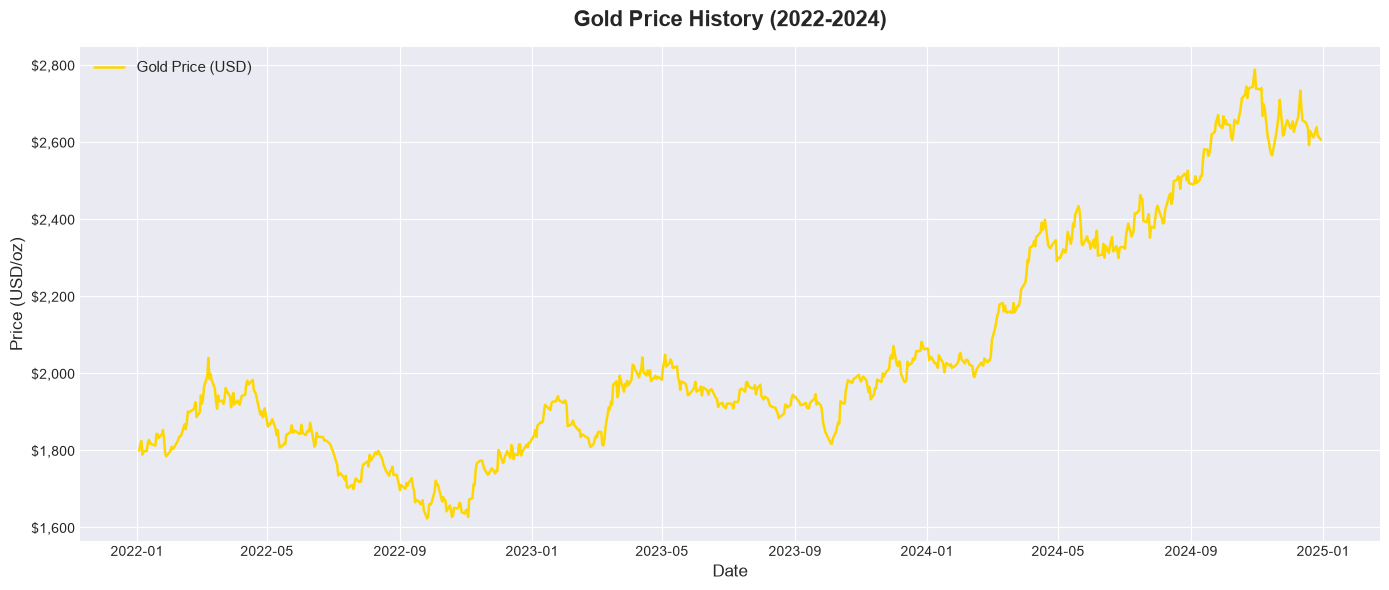

Chart saved.


In [10]:
## Data shows 752 trading days, prices starting around $1,799 in early 2022
## ending around $2,606 around 2024. 45% Move over this period.

fig, ax= plt.subplots(figsize=(14,6))

ax.plot(gold.index, gold["Gold_Price"], color = "#FFD700", linewidth= 1.8, label="Gold Price (USD)")

#Title and labels
ax.set_title("Gold Price History (2022-2024)", fontsize = 16, fontweight = "bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD/oz)", fontsize = 12)
ax.legend(fontsize=11)

# Y axis with dollar signs
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("gold_price_history.png", dpi=150)
plt.show()

print("Chart saved.")

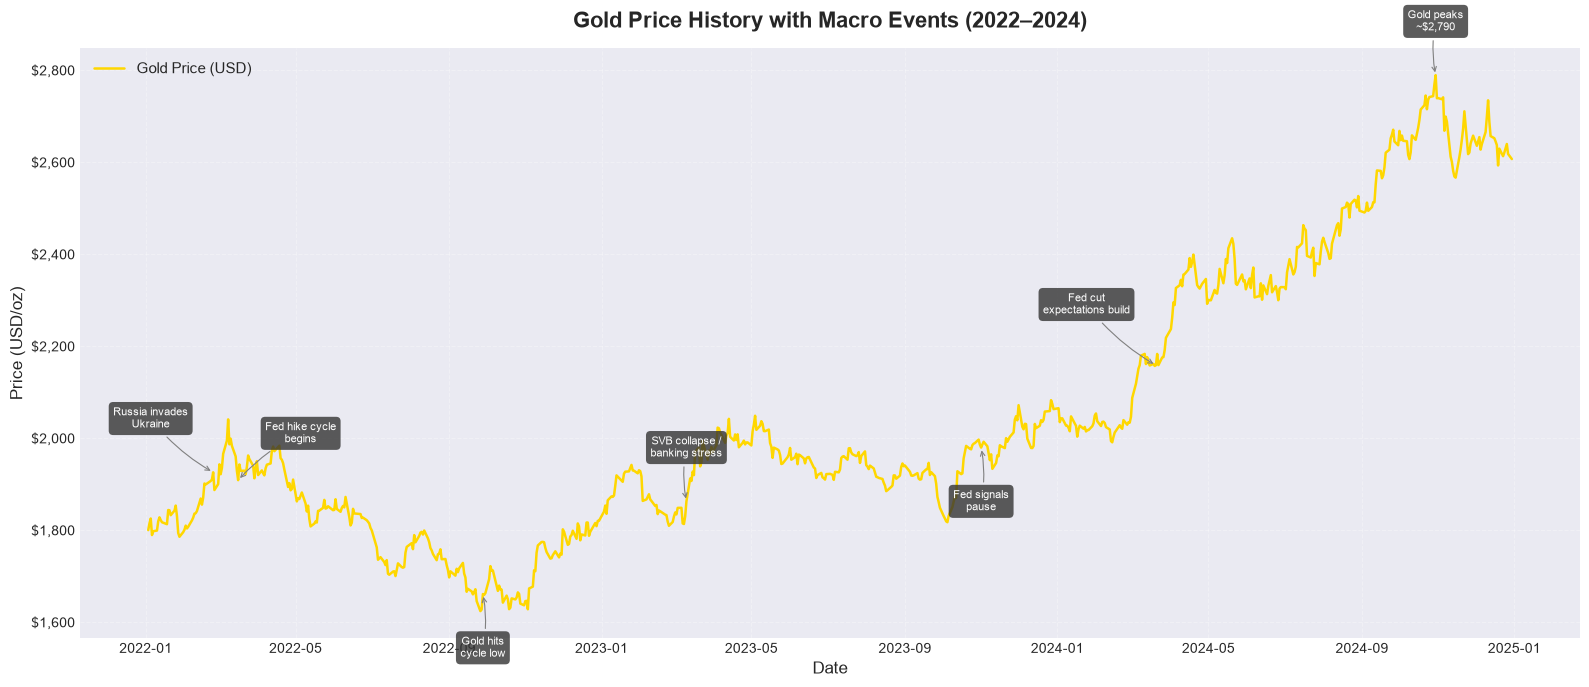

In [13]:
fig, ax = plt.subplots(figsize=(16, 7))

# Plot line
ax.plot(gold.index, gold["Gold_Price"], color="#FFD700", linewidth=1.8, label="Gold Price (USD)")

# Refined annotations array: (date, label, offset_x, offset_y, va)
annotations = [
    ("2022-02-24", "Russia invades\nUkraine", -45, 30, "bottom"),       # Nudged left
    ("2022-03-16", "Fed hike cycle\nbegins", 45, 25, "bottom"),         # Nudged right to clear Ukraine & the future line
    ("2022-09-28", "Gold hits\ncycle low", 0, -30, "top"),    
    ("2023-03-10", "SVB collapse /\nbanking stress", 0, 30, "bottom"),    
    ("2023-11-01", "Fed signals\npause", 0, -30, "top"),    
    ("2024-03-20", "Fed cut\nexpectations build", -50, 35, "bottom"),   # Nudged left to clear the steep rally line
    ("2024-10-30", "Gold peaks\n~$2,790", 0, 30, "bottom"),
]

for date, label, offset_x, offset_y, va in annotations:
    x = pd.Timestamp(date)
    
    # Safe index lookup to prevent weekend KeyErrors
    closest_date = gold.index[gold.index.get_indexer([x], method="nearest")[0]]
    y = gold.loc[closest_date, "Gold_Price"]

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=8,
        ha="center",
        va=va,
        color="white",
        bbox=dict(boxstyle="round,pad=0.4", fc="#333333", alpha=0.8, ec="none"),
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8, connectionstyle="arc3,rad=0.1"),
    )

# Formatting polish
ax.set_title("Gold Price History with Macro Events (2022–2024)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD/oz)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("gold_price_annotated_perfect.png", dpi=150)
plt.show()

## Macro Trend Analysis

Gold's price action from 2022–2024 reflects three distinct phases driven by macro conditions:

**Phase 1 — Selloff (Feb 2022 – Sep 2022)**
Following an initial safe-haven spike driven by Russia's invasion of Ukraine, gold sold off 
sharply as the Federal Reserve launched its most aggressive rate hike cycle in four decades. 
Rising real yields increased the opportunity cost of holding gold, pushing prices from ~$2,050 
down to a cycle low of ~$1,620 by September 2022.

**Phase 2 — Recovery (Oct 2022 – Dec 2023)**
As inflation began cooling and the Fed signaled a slower pace of hikes, gold recovered steadily. 
The March 2023 SVB banking collapse accelerated the move as investors rotated into safe-haven 
assets. Gold reclaimed the $2,000 level and consolidated through the remainder of 2023.

**Phase 3 — Breakout (Jan 2024 – Dec 2024)**
Gold broke out to all-time highs in 2024, driven by building expectations of Fed rate cuts, 
sustained central bank buying, and persistent geopolitical uncertainty. Price advanced from 
~$2,050 to a peak of ~$2,790 — a 36% move within a single calendar year.

---

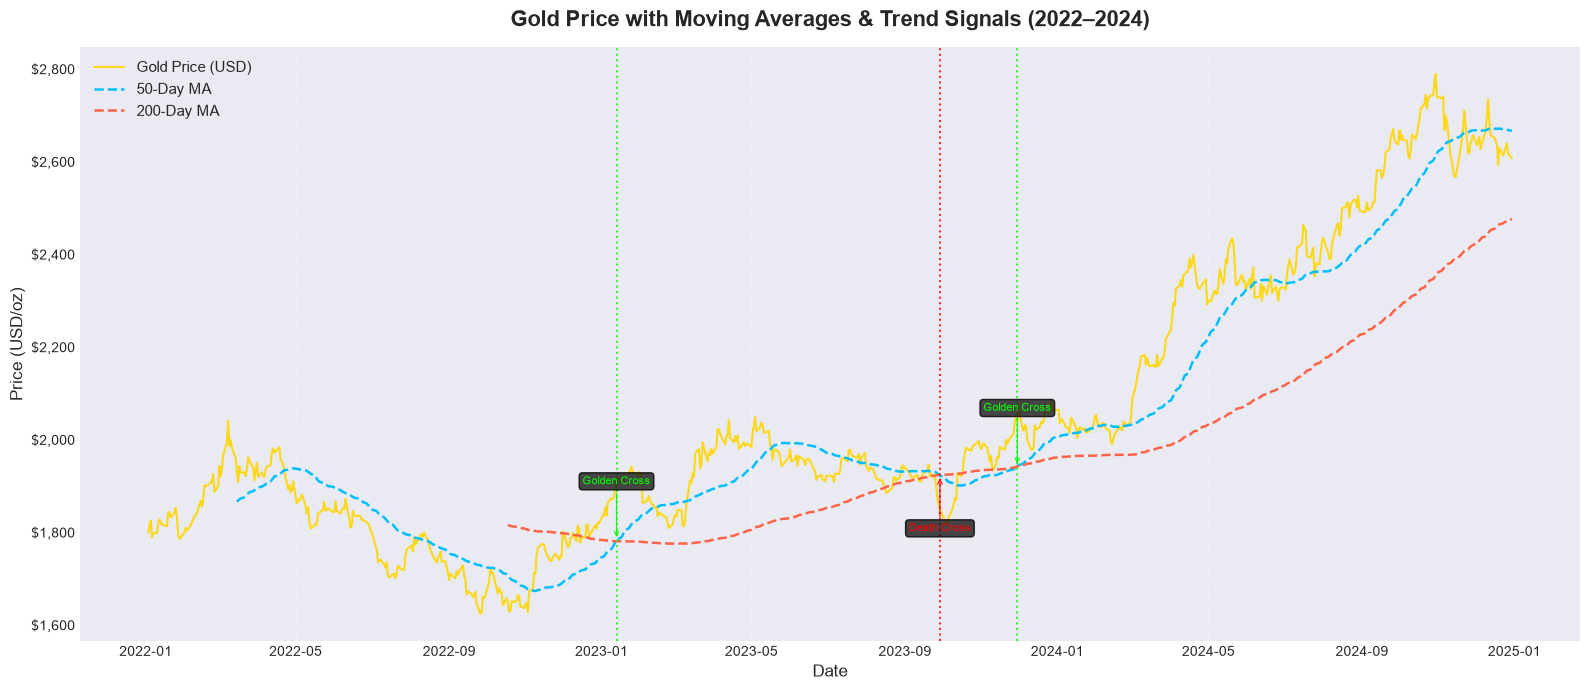

Moving averages chart saved.


In [18]:
# Calculate moving averages
gold["MA_50"] = gold["Gold_Price"].rolling(window=50).mean()
gold["MA_200"] = gold["Gold_Price"].rolling(window=200).mean()

# Filter out NaN warm-up period before checking crossovers
valid_data = gold.dropna(subset=["MA_50", "MA_200"])

# Detect golden cross (bullish) and death cross (bearish)
golden_cross_dates = valid_data[
    (valid_data["MA_50"] > valid_data["MA_200"]) &
    (valid_data["MA_50"].shift(1) <= valid_data["MA_200"].shift(1))
].index

death_cross_dates = valid_data[
    (valid_data["MA_50"] < valid_data["MA_200"]) &
    (valid_data["MA_50"].shift(1) >= valid_data["MA_200"].shift(1))
].index

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(gold.index, gold["Gold_Price"], color="#FFD700", linewidth=1.5, label="Gold Price (USD)", alpha=0.9)
ax.plot(gold.index, gold["MA_50"], color="#00BFFF", linewidth=1.8, linestyle="--", label="50-Day MA")
ax.plot(gold.index, gold["MA_200"], color="#FF6347", linewidth=1.8, linestyle="--", label="200-Day MA")

# Golden cross annotations
for cross in golden_cross_dates:
    closest = gold.index[gold.index.get_indexer([cross], method="nearest")[0]]
    y = gold.loc[closest, "MA_50"]
    ax.axvline(x=closest, color="lime", linestyle=":", linewidth=1.5, alpha=0.8)
    ax.annotate("Golden Cross", xy=(closest, y),
                xytext=(0, 40), textcoords="offset points",
                fontsize=8, ha="center", color="lime",
                bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a1a", alpha=0.8),
                arrowprops=dict(arrowstyle="->", color="lime", lw=0.8))

# Death cross annotations
for cross in death_cross_dates:
    closest = gold.index[gold.index.get_indexer([cross], method="nearest")[0]]
    y = gold.loc[closest, "MA_50"]
    ax.axvline(x=closest, color="red", linestyle=":", linewidth=1.5, alpha=0.8)
    ax.annotate("Death Cross", xy=(closest, y),
                xytext=(0, -40), textcoords="offset points",
                fontsize=8, ha="center", color="red",
                bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a1a", alpha=0.8),
                arrowprops=dict(arrowstyle="->", color="red", lw=0.8))

ax.set_title("Gold Price with Moving Averages & Trend Signals (2022–2024)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD/oz)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("gold_moving_averages.png", dpi=150)
plt.show()

print("Moving averages chart saved.")

## Technical Signal Analysis

Moving average analysis confirmed the bullish structure that developed through 2023 and 2024:

- A **Golden Cross** formed in early 2023 as the 50-day MA crossed above the 200-day MA, 
signaling the end of the downtrend and the beginning of a sustained recovery.
- A brief **Death Cross** appeared in September 2023 during a period of consolidation, 
followed immediately by another **Golden Cross** — a pattern consistent with a shakeout 
before a major trend continuation.
- Through all of 2024, the 50-day MA remained firmly above the 200-day MA, confirming 
sustained bullish momentum and a structurally sound uptrend.

---

In [1]:
from sklearn.linear_model import LinearRegression

# Use last 120 days of data as the basis for the forecast
forecast_window = gold.tail(120).copy()
forecast_window["Days"] = np.arange(len(forecast_window))

# Fit linear regression on recent price trend
# Extract the raw NumPy array values to keep feature names consistent
X = forecast_window[["Days"]].values
y = forecast_window["Gold_Price"].values  # .values works here too

model = LinearRegression()
model.fit(X, y)

# Project 60 trading days forward (~3 months)
future_days = np.arange(len(forecast_window), len(forecast_window) + 60).reshape(-1, 1)
future_prices = model.predict(future_days)

# Build future date index — guaranteed to start on next available business day
start_forecast = gold.index[-1] + pd.Timedelta(days=1)
future_dates = pd.bdate_range(start=start_forecast, periods=60)

# Standard error with expanding uncertainty band
std_error = np.std(y - model.predict(X))
uncertainty_expansion = np.linspace(1.0, 1.5, len(future_dates))
dynamic_band = std_error * uncertainty_expansion

# Plot
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(forecast_window.index, forecast_window["Gold_Price"], color="#FFD700", linewidth=1.8, label="Gold Price (USD)")
ax.plot(forecast_window.index, model.predict(X), color="#00BFFF", linewidth=1.5, linestyle="--", label="Trend (Linear Regression)")
ax.plot(future_dates, future_prices, color="lime", linewidth=2, linestyle="--", label="60-Day Forecast")

ax.fill_between(future_dates, future_prices - dynamic_band, future_prices + dynamic_band,
                color="lime", alpha=0.15, label="Forecast Uncertainty Band")

# Annotate forecast endpoint
ax.annotate(f"Forecast Target\n${future_prices[-1]:,.0f}",
            xy=(future_dates[-1], future_prices[-1]),
            xytext=(-60, 20), textcoords="offset points",
            fontsize=9, color="white",
            bbox=dict(boxstyle="round,pad=0.4", fc="#333333", alpha=0.85),
            arrowprops=dict(arrowstyle="->", color="lime", lw=0.8))

ax.set_title("Gold Price: Short-Term Forecast (60-Day Linear Projection)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD/oz)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("gold_forecast.png", dpi=150)
plt.show()

print(f"Forecast complete. Projected price in 60 trading days: ${future_prices[-1]:,.0f}")

NameError: name 'gold' is not defined

## Investment Thesis — Bullish on Gold

Based on macro trend analysis, technical signals, and momentum-based forecasting, 
this memo presents a bullish thesis on gold with a 60-day price target of **$2,879/oz**.

**Key Drivers Supporting the Thesis:**

**1. Fed Rate Cut Cycle**
The Federal Reserve's pivot from tightening to easing reduces the opportunity cost of 
holding gold. Historically, gold has outperformed during rate cut cycles as real yields 
compress and the dollar weakens.

**2. Central Bank Demand**
Global central banks — particularly in emerging markets — accelerated gold purchases 
through 2023 and 2024 as a hedge against dollar exposure and geopolitical risk. 
This structural demand provides a consistent price floor.

**3. Geopolitical Risk Premium**
Ongoing conflicts and elevated geopolitical uncertainty sustain demand for gold as a 
safe-haven asset. This risk premium is unlikely to dissipate in the near term.

**4. Technical Confirmation**
The sustained Golden Cross structure through 2024, combined with price holding above 
both the 50-day and 200-day moving averages, confirms bullish momentum. The linear 
regression model applied to the trailing 120-day window projects continued appreciation.

**Price Target:** $2,879/oz within 60 trading days of December 2024  
**Bias:** Bullish  
**Conviction:** Moderate-High  
**Primary Risk:** A sharper-than-expected economic slowdown or dollar strengthening 
driven by delayed Fed cuts could compress near-term upside.

---

*Analysis conducted using Python (Pandas, NumPy, Matplotlib, Scikit-learn). 
Data sourced from Yahoo Finance. This memo is for analytical purposes only 
and does not constitute financial advice.*